## 1.Importing Modules

In [192]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline,FeatureUnion
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    MinMaxScaler,
    PowerTransformer,
    FunctionTransformer,
    StandardScaler
)
from feature_engine.outliers import Winsorizer
from feature_engine.encoding import (RareLabelEncoder,
                                     MeanEncoder,
                                     CountFrequencyEncoder)
from feature_engine.datetime import DatetimeFeatures
from feature_engine.selection import SelectBySingleFeaturePerformance
from feature_engine.encoding import MeanEncoder

import matplotlib.pyplot as plt
import warnings
import os

### 2.Display Settings

In [138]:
pd.set_option("display.max_columns", None) # display all the columns

In [139]:
# sklearn transformer byb default return numpy array as an output,
# but if we want df as an output itself, we write this code
sklearn.set_config(transform_output="pandas") 

In [140]:
warnings.filterwarnings("ignore")

### Read Data

In [141]:
PROJECT_DIR = r"C:\Users\Naruto\Desktop\generative_ai\PROJECTS\flight_price_prediction"
DATA_DIR = "data"

In [142]:
def get_data(name):
	file_name = f"{name}.csv"
	file_path = os.path.join(PROJECT_DIR, DATA_DIR, file_name)
	return pd.read_csv(file_path)

In [143]:
train = get_data("train")
train.head(5)

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Jet Airways,2019-03-18,Banglore,New Delhi,16:55:00,23:00:00,365,1.0,No Info,13555
1,Indigo,2019-06-09,Banglore,Delhi,08:30:00,11:20:00,170,0.0,No Info,4823
2,Indigo,2019-05-18,Kolkata,Banglore,04:40:00,07:15:00,155,0.0,No Info,4804
3,Jet Airways,2019-05-18,Kolkata,Banglore,14:05:00,19:50:00,345,1.0,No Info,14781
4,Spicejet,2019-05-09,Kolkata,Banglore,17:10:00,19:40:00,150,0.0,No Info,3873


In [144]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          640 non-null    object 
 1   date_of_journey  640 non-null    object 
 2   source           640 non-null    object 
 3   destination      640 non-null    object 
 4   dep_time         640 non-null    object 
 5   arrival_time     640 non-null    object 
 6   duration         640 non-null    int64  
 7   total_stops      640 non-null    float64
 8   additional_info  640 non-null    object 
 9   price            640 non-null    int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 50.1+ KB


In [145]:
X_train =train.drop(columns="price")
y_train = train.price.copy()

### 4.Transformation Operation

In [146]:
X_train.columns.to_list()

['airline',
 'date_of_journey',
 'source',
 'destination',
 'dep_time',
 'arrival_time',
 'duration',
 'total_stops',
 'additional_info']

#### 4.1 airline 
- categorical column

In [147]:
air_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("grouper",RareLabelEncoder(tol=0.1, replace_with="Other", n_categories=2)),
        ("encoder",OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ])
# grouper:
# tol=0.1 : any category less then 10 it will group them all
# replace_with="Other" : means name that group=Other
# n_categories=2 : means group only when feature having at least two categories in it.

air_transformer.fit_transform(X_train.loc[:,["airline"]])

,airline_Air India,airline_Indigo,airline_Jet Airways,airline_Multiple Carriers,airline_Other
0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
635,0.0,1.0,0.0,0.0,0.0
636,0.0,0.0,1.0,0.0,0.0
637,0.0,0.0,1.0,0.0,0.0
638,0.0,0.0,1.0,0.0,0.0


#### 4.2 date_of_joiurney

In [148]:
X_train.date_of_journey

0      2019-03-18
1      2019-06-09
2      2019-05-18
3      2019-05-18
4      2019-05-09
          ...    
635    2019-03-24
636    2019-06-06
637    2019-06-12
638    2019-03-21
639    2019-06-27
Name: date_of_journey, Length: 640, dtype: object

In [149]:

feature_to_extract = ["month", "week", "day_of_week", "day_of_year"]

doj_transformer = Pipeline(steps=[
	("dt", DatetimeFeatures(features_to_extract=feature_to_extract, yearfirst=True, format="mixed")),
	("scaler", MinMaxScaler())
])

doj_transformer.fit_transform(X_train.loc[:, ["date_of_journey"]])

,date_of_journey_month,date_of_journey_week,date_of_journey_day_of_week,date_of_journey_day_of_year
0,0.000000,0.176471,0.000000,0.144068
1,1.000000,0.823529,1.000000,0.847458
2,0.666667,0.647059,0.833333,0.661017
3,0.666667,0.647059,0.833333,0.661017
4,0.666667,0.588235,0.500000,0.584746
...,...,...,...,...
635,0.000000,0.176471,1.000000,0.194915
636,1.000000,0.823529,0.500000,0.822034
637,1.000000,0.882353,0.333333,0.872881
638,0.000000,0.176471,0.500000,0.169492


#### 4.3 source & destination

In [150]:
X_train.source

0      Banglore
1      Banglore
2       Kolkata
3       Kolkata
4       Kolkata
         ...   
635    Banglore
636     Kolkata
637       Delhi
638       Delhi
639    Banglore
Name: source, Length: 640, dtype: object

In [151]:
X_train.destination

0      New Delhi
1          Delhi
2       Banglore
3       Banglore
4       Banglore
         ...    
635    New Delhi
636     Banglore
637       Cochin
638       Cochin
639        Delhi
Name: destination, Length: 640, dtype: object

In [152]:
location_subset = X_train.loc[:, ["source","destination"]]
location_subset

,source,destination
0,Banglore,New Delhi
1,Banglore,Delhi
2,Kolkata,Banglore
3,Kolkata,Banglore
4,Kolkata,Banglore
...,...,...
635,Banglore,New Delhi
636,Kolkata,Banglore
637,Delhi,Cochin
638,Delhi,Cochin


In [153]:
location_pipe1 = Pipeline(steps=[
    ("grouper", RareLabelEncoder(tol=0.1, replace_with="Other", n_categories=2)),
    ("mean_encoding", MeanEncoder()),
    ("pw_scalling",PowerTransformer()) # 
])
location_pipe1.fit_transform(location_subset,y_train)

,source,destination
0,-0.752443,-0.706170
1,-0.752443,-1.777299
2,-0.226206,-0.214442
3,-0.226206,-0.214442
4,-0.226206,-0.214442
...,...,...
635,-0.752443,-0.706170
636,-0.226206,-0.214442
637,1.028125,1.027069
638,1.028125,1.027069


In [154]:
np.union1d(
    X_train.source.unique(),
    X_train.destination.unique()
)

array(['Banglore', 'Chennai', 'Cochin', 'Delhi', 'Hyderabad', 'Kolkata',
       'Mumbai', 'New Delhi'], dtype=object)

In [155]:
def is_north(X):
    columns = X.columns.to_list()
    north_cities = ["Delhi", "Kolkata", "Mumbai", "New Delhi"]
    return (
        X
        .assign(**{
            f"{col}_is_north": X.loc[:, col].isin(north_cities).astype(int)
            for col in columns
        })
        .drop(columns=columns)
    )

# to make user_defined function Pipeline compatible we use FunctionTransformer
# is_north = FunctionTransformer(func=is_north)

In [156]:
location_transformer = FeatureUnion(transformer_list=[
	("part1", location_pipe1),
	("part2", FunctionTransformer(func=is_north))
])

location_transformer.fit_transform(location_subset, y_train)

,source,destination,source_is_north,destination_is_north
0,-0.752443,-0.706170,0,1
1,-0.752443,-1.777299,0,1
2,-0.226206,-0.214442,1,0
3,-0.226206,-0.214442,1,0
4,-0.226206,-0.214442,1,0
...,...,...,...,...
635,-0.752443,-0.706170,0,1
636,-0.226206,-0.214442,1,0
637,1.028125,1.027069,1,0
638,1.028125,1.027069,1,0


### 4.4 dep_time & arrival_time

In [157]:
time_subset = X_train.loc[:, ["dep_time", "arrival_time"]]
time_subset

,dep_time,arrival_time
0,16:55:00,23:00:00
1,08:30:00,11:20:00
2,04:40:00,07:15:00
3,14:05:00,19:50:00
4,17:10:00,19:40:00
...,...,...
635,21:20:00,00:15:00
636,09:35:00,21:05:00
637,20:55:00,19:00:00
638,05:30:00,18:50:00


In [158]:
time_pipe1 = Pipeline(steps=[
    ("dt", DatetimeFeatures(features_to_extract=["hour", "minute"])),
    ("scaler", MinMaxScaler())
])
time_pipe1.fit_transform(time_subset)

,dep_time_hour,dep_time_minute,arrival_time_hour,arrival_time_minute
0,0.695652,1.000000,1.000000,0.000000
1,0.347826,0.545455,0.478261,0.363636
2,0.173913,0.727273,0.304348,0.272727
3,0.608696,0.090909,0.826087,0.909091
4,0.739130,0.181818,0.826087,0.727273
...,...,...,...,...
635,0.913043,0.363636,0.000000,0.272727
636,0.391304,0.636364,0.913043,0.090909
637,0.869565,1.000000,0.826087,0.000000
638,0.217391,0.545455,0.782609,0.909091


In [159]:
def part_of_day(X,morning=4, noon=12, eve=16, night=20):
    columns = X.columns.to_list()
    X_temp = X.assign(**{
        col: pd.to_datetime(X.loc[:,col]).dt.hour
        for col in columns
    })
    return (
        X_temp
        .assign(**{
            f"{col}_part_of_day": np.select(
                [X_temp.loc[:,col].between(morning, noon, inclusive="left"),
                X_temp.loc[:,col].between(noon, eve, inclusive="left"),
                X_temp.loc[:,col].between(eve, night, inclusive="left")],
                ["mornign", "afternoon", "evening"],
                default="night"
            )
            for col in columns
        })
        .drop(columns=columns)
    )
FunctionTransformer(func=part_of_day).fit_transform(time_subset)

,dep_time_part_of_day,arrival_time_part_of_day
0,evening,night
1,mornign,mornign
2,mornign,mornign
3,afternoon,evening
4,evening,evening
...,...,...
635,night,night
636,mornign,night
637,night,evening
638,mornign,evening


In [160]:
time_pipe2 = Pipeline(steps=[
	("part", FunctionTransformer(func=part_of_day)),
	("encoder", CountFrequencyEncoder()),
	("scaler", MinMaxScaler())
])

time_pipe2.fit_transform(time_subset)

,dep_time_part_of_day,arrival_time_part_of_day
0,0.258929,1.000000
1,1.000000,0.913793
2,1.000000,0.913793
3,0.000000,0.568966
4,0.258929,0.568966
...,...,...
635,0.223214,1.000000
636,1.000000,1.000000
637,0.223214,0.568966
638,1.000000,0.568966


In [161]:

time_transformer = FeatureUnion(transformer_list=[
	("part1", time_pipe1),
	("part2", time_pipe2)
])

time_transformer.fit_transform(time_subset)

,dep_time_hour,dep_time_minute,arrival_time_hour,arrival_time_minute,dep_time_part_of_day,arrival_time_part_of_day
0,0.695652,1.000000,1.000000,0.000000,0.258929,1.000000
1,0.347826,0.545455,0.478261,0.363636,1.000000,0.913793
2,0.173913,0.727273,0.304348,0.272727,1.000000,0.913793
3,0.608696,0.090909,0.826087,0.909091,0.000000,0.568966
4,0.739130,0.181818,0.826087,0.727273,0.258929,0.568966
...,...,...,...,...,...,...
635,0.913043,0.363636,0.000000,0.272727,0.223214,1.000000
636,0.391304,0.636364,0.913043,0.090909,1.000000,1.000000
637,0.869565,1.000000,0.826087,0.000000,0.223214,0.568966
638,0.217391,0.545455,0.782609,0.909091,1.000000,0.568966


### 4.5 Duration

In [162]:
X_train.duration

0       365
1       170
2       155
3       345
4       150
       ... 
635     175
636     690
637    1325
638    2240
639     185
Name: duration, Length: 640, dtype: int64

In [163]:
duration_subset = X_train.loc[:, ["duration"]]
duration_subset

,duration
0,365
1,170
2,155
3,345
4,150
...,...
635,175
636,690
637,1325
638,2240


In [164]:
## <180 minutes short
##  between [180,400] medium
## else: large

def mark_duration_of_flight(X,min1=180,min2=400):
    columns = X.columns
    print(columns)
    condition = [(X['duration']>=400)]
    return (
        X
        .assign(**{
            f"{col}_flight": np.select(
                [X[col].between(0,min1,inclusive="left"),
                 X[col].between(min1,min2,inclusive="left"),
                #  X[col]>min2],
                 X[col].ge(min2)],
                 ["short","medium","large"],
                 default = "late"
            )
            for col in columns 
        })
        .drop(columns=columns)
    )

# mark_duration_of_flight(pd.DataFrame(X_train["duration"]))
# mark_duration_of_flight(duration_subse(t)
FunctionTransformer(func=mark_duration_of_flight).fit_transform(duration_subset)

Index(['duration'], dtype='object')


,duration_flight
0,medium
1,short
2,short
3,medium
4,short
...,...
635,short
636,large
637,large
638,large


In [165]:
(
X_train.duration
.quantile([0.25,0.5,0.75]).values
.reshape(1,-1)
# .shape
)

array([[170., 470., 920.]])

In [166]:
class RBFPercentileSimilarity(BaseEstimator, TransformerMixin):
	def __init__(self, variables=None, percentiles=[0.25, 0.5, 0.75], gamma=0.1):
		self.variables = variables
		self.percentiles = percentiles
		self.gamma = gamma


	def fit(self, X, y=None):
		if not self.variables:
			self.variables = X.select_dtypes(include="number").columns.to_list()

		self.reference_values_ = {
			col: (
				X
				.loc[:, col]
				.quantile(self.percentiles)
				.values
				.reshape(-1, 1)
			)
			for col in self.variables
		}

		return self


	def transform(self, X):
		objects = []
		for col in self.variables:
			columns = [f"{col}_rbf_{int(percentile * 100)}" for percentile in self.percentiles]
			obj = pd.DataFrame(
				data=rbf_kernel(X.loc[:, [col]], Y=self.reference_values_[col], gamma=self.gamma),
				columns=columns
			)
			objects.append(obj)
		return pd.concat(objects, axis=1)

In [167]:
RBFPercentileSimilarity(percentiles=[0.4,0.8]).fit_transform(X_train)
#alternative
# RBFPercentileSimilarity(percentiles=[0.4,0.8]).fit(X_train).transform(X_train)
# THIS IS CALLED AS METHOD CHAINING

,duration_rbf_40,duration_rbf_80,total_stops_rbf_40,total_stops_rbf_80
0,6.293989e-54,0.0,1.000000,1.000000
1,0.000000e+00,0.0,0.904837,0.904837
2,0.000000e+00,0.0,0.904837,0.904837
3,1.691898e-10,0.0,1.000000,1.000000
4,0.000000e+00,0.0,0.904837,0.904837
...,...,...,...,...
635,0.000000e+00,0.0,0.904837,0.904837
636,0.000000e+00,0.0,1.000000,1.000000
637,0.000000e+00,0.0,1.000000,1.000000
638,0.000000e+00,0.0,0.904837,0.904837


In [168]:

def duration_category(X, short=180, med=400):
	return (
		X
		.assign(duration_cat=np.select([X.duration.lt(short),
									    X.duration.between(short, med, inclusive="left")],
									   ["short", "medium"],
									   default="long"))
		.drop(columns="duration")
	)

In [169]:
def is_over(X, value=1000):
	return (
		X
		.assign(**{
			f"duration_over_{value}": X.duration.ge(value).astype(int)
		})
		.drop(columns="duration")
	)

In [170]:
duration_pipe1 = Pipeline(steps=[
	("rbf", RBFPercentileSimilarity()),
	("scaler", PowerTransformer())
])

duration_pipe2 = Pipeline(steps=[
	("cat", FunctionTransformer(func=duration_category)),
	("encoder", OrdinalEncoder(categories=[["short", "medium", "long"]]))
    # ("encoder", OrdinalEncoder(mapping=[{'col': 'duration', 'mapping': {'short': 1, 'medium': 2, 'long': 3}}]))
])

duration_union = FeatureUnion(transformer_list=[
	("part1", duration_pipe1),
	("part2", duration_pipe2),
	("part3", FunctionTransformer(func=is_over)),
	("part4", StandardScaler())
])

duration_transformer = Pipeline(steps=[
	("outliers", Winsorizer(capping_method="iqr", fold=1.5)),
	("imputer", SimpleImputer(strategy="median")),
	("union", duration_union)
])

duration_transformer.fit_transform(X_train.loc[:, ["duration"]])

,duration_rbf_25,duration_rbf_50,duration_rbf_75,duration_cat,duration_over_1000,duration
0,-0.358014,-0.089818,-0.070842,1.0,0,-0.521830
1,3.124152,-0.089818,-0.070842,0.0,0,-0.904678
2,-0.358014,-0.089818,-0.070842,0.0,0,-0.934128
3,-0.358014,-0.089818,-0.070842,1.0,0,-0.561096
4,-0.358014,-0.089818,-0.070842,0.0,0,-0.943944
...,...,...,...,...,...,...
635,2.282240,-0.089818,-0.070842,0.0,0,-0.894861
636,-0.358014,-0.089818,-0.070842,2.0,0,0.116250
637,-0.358014,-0.089818,-0.070842,2.0,1,1.362961
638,-0.358014,-0.089818,-0.070842,2.0,1,2.776553


### 4.6 total_stops

In [171]:
X_train.total_stops

0      1.0
1      0.0
2      0.0
3      1.0
4      0.0
      ... 
635    0.0
636    1.0
637    1.0
638    2.0
639    0.0
Name: total_stops, Length: 640, dtype: float64

In [172]:
def is_direct(X):
	return X.assign(is_direct_flight=X.total_stops.eq(0).astype(int))


total_stops_transformer = Pipeline(steps=[
	("imputer", SimpleImputer(strategy="most_frequent")),
	("", FunctionTransformer(func=is_direct))
])

total_stops_transformer.fit_transform(X_train.loc[:, ["total_stops"]])

,total_stops,is_direct_flight
0,1.0,0
1,0.0,1
2,0.0,1
3,1.0,0
4,0.0,1
...,...,...
635,0.0,1
636,1.0,0
637,1.0,0
638,2.0,0


### 4.7 additional_info

In [173]:
X_train.additional_info

0                          No Info
1                          No Info
2                          No Info
3                          No Info
4                          No Info
                  ...             
635                        No Info
636                        No Info
637    In-flight meal not included
638    In-flight meal not included
639    In-flight meal not included
Name: additional_info, Length: 640, dtype: object

In [174]:
info_pipe1 = Pipeline(steps=[
	("group", RareLabelEncoder(tol=0.1, n_categories=2, replace_with="Other")),
	("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

info_pipe1.fit_transform(X_train.loc[:, ["additional_info"]])

,additional_info_In-flight meal not included,additional_info_No Info,additional_info_Other
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
635,0.0,1.0,0.0
636,0.0,1.0,0.0
637,1.0,0.0,0.0
638,1.0,0.0,0.0


In [175]:
def have_info(X):
	return X.assign(additional_info=X.additional_info.ne("No Info").astype(int))

In [176]:
info_union = FeatureUnion(transformer_list=[
	("part1", info_pipe1),
	("part2", FunctionTransformer(func=have_info))
])

In [177]:
info_transformer = Pipeline(steps=[
	("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
	("union", info_union)
])

info_transformer.fit_transform(X_train.loc[:, ["additional_info"]])

,additional_info_In-flight meal not included,additional_info_No Info,additional_info_Other,additional_info
0,0.0,1.0,0.0,0
1,0.0,1.0,0.0,0
2,0.0,1.0,0.0,0
3,0.0,1.0,0.0,0
4,0.0,1.0,0.0,0
...,...,...,...,...
635,0.0,1.0,0.0,0
636,0.0,1.0,0.0,0
637,1.0,0.0,0.0,1
638,1.0,0.0,0.0,1


### 4.8 Column Transformer

In [178]:
column_transformer = ColumnTransformer(transformers=[
	("air", air_transformer, ["airline"]),
	("doj", doj_transformer, ["date_of_journey"]),
	("location", location_transformer, ["source", 'destination']),
	("time", time_transformer, ["dep_time", "arrival_time"]),
	("dur", duration_transformer, ["duration"]),
	("stops", total_stops_transformer, ["total_stops"]),
	("info", info_transformer, ["additional_info"])
], remainder="passthrough")

column_transformer.fit_transform(X_train, y_train)

,air__airline_Air India,air__airline_Indigo,air__airline_Jet Airways,air__airline_Multiple Carriers,air__airline_Other,doj__date_of_journey_month,doj__date_of_journey_week,doj__date_of_journey_day_of_week,doj__date_of_journey_day_of_year,location__source,location__destination,location__source_is_north,location__destination_is_north,time__dep_time_hour,time__dep_time_minute,time__arrival_time_hour,time__arrival_time_minute,time__dep_time_part_of_day,time__arrival_time_part_of_day,dur__duration_rbf_25,dur__duration_rbf_50,dur__duration_rbf_75,dur__duration_cat,dur__duration_over_1000,dur__duration,stops__total_stops,stops__is_direct_flight,info__additional_info_In-flight meal not included,info__additional_info_No Info,info__additional_info_Other,info__additional_info
0,0.0,0.0,1.0,0.0,0.0,0.000000,0.176471,0.000000,0.144068,-0.752443,-0.706170,0,1,0.695652,1.000000,1.000000,0.000000,0.258929,1.000000,-0.358014,-0.089818,-0.070842,1.0,0,-0.521830,1.0,0,0.0,1.0,0.0,0
1,0.0,1.0,0.0,0.0,0.0,1.000000,0.823529,1.000000,0.847458,-0.752443,-1.777299,0,1,0.347826,0.545455,0.478261,0.363636,1.000000,0.913793,3.124152,-0.089818,-0.070842,0.0,0,-0.904678,0.0,1,0.0,1.0,0.0,0
2,0.0,1.0,0.0,0.0,0.0,0.666667,0.647059,0.833333,0.661017,-0.226206,-0.214442,1,0,0.173913,0.727273,0.304348,0.272727,1.000000,0.913793,-0.358014,-0.089818,-0.070842,0.0,0,-0.934128,0.0,1,0.0,1.0,0.0,0
3,0.0,0.0,1.0,0.0,0.0,0.666667,0.647059,0.833333,0.661017,-0.226206,-0.214442,1,0,0.608696,0.090909,0.826087,0.909091,0.000000,0.568966,-0.358014,-0.089818,-0.070842,1.0,0,-0.561096,1.0,0,0.0,1.0,0.0,0
4,0.0,0.0,0.0,0.0,1.0,0.666667,0.588235,0.500000,0.584746,-0.226206,-0.214442,1,0,0.739130,0.181818,0.826087,0.727273,0.258929,0.568966,-0.358014,-0.089818,-0.070842,0.0,0,-0.943944,0.0,1,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635,0.0,1.0,0.0,0.0,0.0,0.000000,0.176471,1.000000,0.194915,-0.752443,-0.706170,0,1,0.913043,0.363636,0.000000,0.272727,0.223214,1.000000,2.282240,-0.089818,-0.070842,0.0,0,-0.894861,0.0,1,0.0,1.0,0.0,0
636,0.0,0.0,1.0,0.0,0.0,1.000000,0.823529,0.500000,0.822034,-0.226206,-0.214442,1,0,0.391304,0.636364,0.913043,0.090909,1.000000,1.000000,-0.358014,-0.089818,-0.070842,2.0,0,0.116250,1.0,0,0.0,1.0,0.0,0
637,0.0,0.0,1.0,0.0,0.0,1.000000,0.882353,0.333333,0.872881,1.028125,1.027069,1,0,0.869565,1.000000,0.826087,0.000000,0.223214,0.568966,-0.358014,-0.089818,-0.070842,2.0,1,1.362961,1.0,0,1.0,0.0,0.0,1
638,0.0,0.0,1.0,0.0,0.0,0.000000,0.176471,0.500000,0.169492,1.028125,1.027069,1,0,0.217391,0.545455,0.782609,0.909091,1.000000,0.568966,-0.358014,-0.089818,-0.070842,2.0,1,2.776553,2.0,0,1.0,0.0,0.0,1


### 5. Feature Selection

In [179]:
estimator = RandomForestRegressor(n_estimators=10, max_depth=3, random_state=42)

selector = SelectBySingleFeaturePerformance(
	estimator=estimator,
	scoring="r2",
	threshold=0.1
)

In [180]:
preprocessor = Pipeline(steps=[
	("ct", column_transformer),
	("selector", selector)
])

preprocessor.fit_transform(X_train, y_train)

,air__airline_Indigo,air__airline_Jet Airways,doj__date_of_journey_day_of_year,location__source,location__destination,dur__duration_cat,dur__duration,stops__total_stops,stops__is_direct_flight
0,0.0,1.0,0.144068,-0.752443,-0.706170,1.0,-0.521830,1.0,0
1,1.0,0.0,0.847458,-0.752443,-1.777299,0.0,-0.904678,0.0,1
2,1.0,0.0,0.661017,-0.226206,-0.214442,0.0,-0.934128,0.0,1
3,0.0,1.0,0.661017,-0.226206,-0.214442,1.0,-0.561096,1.0,0
4,0.0,0.0,0.584746,-0.226206,-0.214442,0.0,-0.943944,0.0,1
...,...,...,...,...,...,...,...,...,...
635,1.0,0.0,0.194915,-0.752443,-0.706170,0.0,-0.894861,0.0,1
636,0.0,1.0,0.822034,-0.226206,-0.214442,2.0,0.116250,1.0,0
637,0.0,1.0,0.872881,1.028125,1.027069,2.0,1.362961,1.0,0
638,0.0,1.0,0.169492,1.028125,1.027069,2.0,2.776553,2.0,0


### 6. Putting it all Together

In [181]:
preprocessor

Pipeline(steps=[('ct',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('air',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('grouper',
                                                                   RareLabelEncoder(n_categories=2,
                                                                                    replace_with='Other',
                                                                                    tol=0.1)),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['airline']),
                                                 ('doj',
                                                  Pipeline(steps=[('dt',
                                                                   Datetime...
                                                                                                                                     replace_with='Other',
                                                                                                                                     tol=0.1)),
                                                                                                                   ('encoder',
                                                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                                                  sparse_output=False))])),
                                                                                                  ('part2',
                                                                                                   FunctionTransformer(func=<function have_info at 0x00000162D50E13A0>))]))]),
                                                  ['additional_info'])])),
                ('selector',
                 SelectBySingleFeaturePerformance(estimator=RandomForestRegressor(max_depth=3,
                                                                                  n_estimators=10,
                                                                                  random_state=42),
                                                  scoring='r2',
                                                  threshold=0.1))])

### 7. Visualizations

In [186]:
preprocessor.named_steps['selector']

SelectBySingleFeaturePerformance(estimator=RandomForestRegressor(max_depth=3,
                                                                 n_estimators=10,
                                                                 random_state=42),
                                 scoring='r2', threshold=0.1)

In [188]:
preprocessor.named_steps['selector'].feature_performance_

{'air__airline_Air India': -0.014209880641193365,
 'air__airline_Indigo': 0.13656656749064142,
 'air__airline_Jet Airways': 0.17348620293327588,
 'air__airline_Multiple Carriers': -0.0022199227377700526,
 'air__airline_Other': 0.07788685564060453,
 'doj__date_of_journey_month': 0.05991737671265288,
 'doj__date_of_journey_week': 0.09200813787829383,
 'doj__date_of_journey_day_of_week': -0.018200491963587268,
 'doj__date_of_journey_day_of_year': 0.10144092072125528,
 'location__source': 0.13648842474281941,
 'location__destination': 0.11637013327925035,
 'location__source_is_north': 0.013961184666613188,
 'location__destination_is_north': 0.013961184666613188,
 'time__dep_time_hour': -0.06702782408095824,
 'time__dep_time_minute': -0.018632645111359498,
 'time__arrival_time_hour': 0.04261403573895813,
 'time__arrival_time_minute': -0.02663500901623776,
 'time__dep_time_part_of_day': -0.03322867817456535,
 'time__arrival_time_part_of_day': 0.012716879075873858,
 'dur__duration_rbf_25': 0.

In [189]:

feature_performances = preprocessor.named_steps["selector"].feature_performance_
feature_performances

{'air__airline_Air India': -0.014209880641193365,
 'air__airline_Indigo': 0.13656656749064142,
 'air__airline_Jet Airways': 0.17348620293327588,
 'air__airline_Multiple Carriers': -0.0022199227377700526,
 'air__airline_Other': 0.07788685564060453,
 'doj__date_of_journey_month': 0.05991737671265288,
 'doj__date_of_journey_week': 0.09200813787829383,
 'doj__date_of_journey_day_of_week': -0.018200491963587268,
 'doj__date_of_journey_day_of_year': 0.10144092072125528,
 'location__source': 0.13648842474281941,
 'location__destination': 0.11637013327925035,
 'location__source_is_north': 0.013961184666613188,
 'location__destination_is_north': 0.013961184666613188,
 'time__dep_time_hour': -0.06702782408095824,
 'time__dep_time_minute': -0.018632645111359498,
 'time__arrival_time_hour': 0.04261403573895813,
 'time__arrival_time_minute': -0.02663500901623776,
 'time__dep_time_part_of_day': -0.03322867817456535,
 'time__arrival_time_part_of_day': 0.012716879075873858,
 'dur__duration_rbf_25': 0.

In [190]:
sorted_feat_imp = dict(sorted(feature_performances.items(), key=lambda val: val[1]))
sorted_feat_imp

{'time__dep_time_hour': -0.06702782408095824,
 'time__dep_time_part_of_day': -0.03322867817456535,
 'time__arrival_time_minute': -0.02663500901623776,
 'time__dep_time_minute': -0.018632645111359498,
 'doj__date_of_journey_day_of_week': -0.018200491963587268,
 'dur__duration_rbf_50': -0.01701873276598631,
 'info__additional_info_In-flight meal not included': -0.014553525031523629,
 'air__airline_Air India': -0.014209880641193365,
 'info__additional_info_No Info': -0.013744311081307655,
 'info__additional_info': -0.013744311081307655,
 'dur__duration_rbf_75': -0.012324151809892733,
 'air__airline_Multiple Carriers': -0.0022199227377700526,
 'time__arrival_time_part_of_day': 0.012716879075873858,
 'location__source_is_north': 0.013961184666613188,
 'location__destination_is_north': 0.013961184666613188,
 'info__additional_info_Other': 0.016321709157506154,
 'time__arrival_time_hour': 0.04261403573895813,
 'doj__date_of_journey_month': 0.05991737671265288,
 'air__airline_Other': 0.0778868

In [191]:
preprocessor = Pipeline(steps=[
	("ct", column_transformer),
	("selector", selector)
])
preprocessor.fit_transform(X_train, y_train)

,air__airline_Indigo,air__airline_Jet Airways,doj__date_of_journey_day_of_year,location__source,location__destination,dur__duration_cat,dur__duration,stops__total_stops,stops__is_direct_flight
0,0.0,1.0,0.144068,-0.752443,-0.706170,1.0,-0.521830,1.0,0
1,1.0,0.0,0.847458,-0.752443,-1.777299,0.0,-0.904678,0.0,1
2,1.0,0.0,0.661017,-0.226206,-0.214442,0.0,-0.934128,0.0,1
3,0.0,1.0,0.661017,-0.226206,-0.214442,1.0,-0.561096,1.0,0
4,0.0,0.0,0.584746,-0.226206,-0.214442,0.0,-0.943944,0.0,1
...,...,...,...,...,...,...,...,...,...
635,1.0,0.0,0.194915,-0.752443,-0.706170,0.0,-0.894861,0.0,1
636,0.0,1.0,0.822034,-0.226206,-0.214442,2.0,0.116250,1.0,0
637,0.0,1.0,0.872881,1.028125,1.027069,2.0,1.362961,1.0,0
638,0.0,1.0,0.169492,1.028125,1.027069,2.0,2.776553,2.0,0


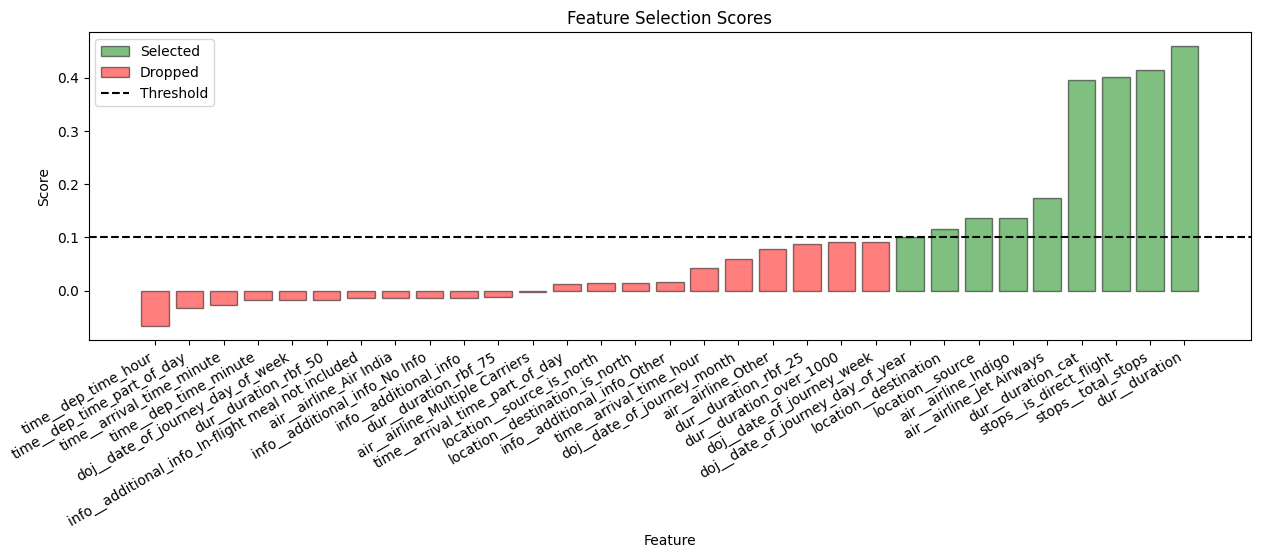

In [193]:
THRESHOLD = 0.1

selected_bar = None
dropped_bar = None
colors = ["red" if score < THRESHOLD else "green" for score in sorted_feat_imp.values()]


fig, ax = plt.subplots(figsize=(15, 4))

for i, (feature, score) in enumerate(sorted_feat_imp.items()):
	params = dict(
		x=i,
		height=score,
		edgecolor="black",
		alpha=0.5
	)
	
	if score < THRESHOLD:
		bar = ax.bar(
			color="red",
			**params
		)
		if not dropped_bar:
			dropped_bar = bar[0]
	else:
		bar = ax.bar(
			color="green",
			**params
		)
		if not selected_bar:
			selected_bar = bar[0]

thresh_line = ax.axhline(
	y=0.1,
	color="black",
	linestyle="--"
)

ax.set_xticks(
	ticks=range(len(sorted_feat_imp)),
	labels=list(sorted_feat_imp.keys()),
	rotation=30,
	ha="right"
)

ax.set(
	xlabel="Feature",
	ylabel="Score",
	title="Feature Selection Scores"
)

ax.legend(
	handles=[selected_bar, dropped_bar, thresh_line],
	labels=["Selected", "Dropped", "Threshold"],
	loc="upper left"
)

plt.show()